In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import *

In [3]:
# Load dataset
ds = load_jsonl_file('./../datasets/MATE-dev/mm_0shot_llava_hfllava_1.5_7b_hf.jsonl')
nobjects=[3,7,10]

# Filter dataset for a specific number of objects 
ds_ = [data for data in ds if data['object_count'] in nobjects]

5500it [00:00, 7813.38it/s] 


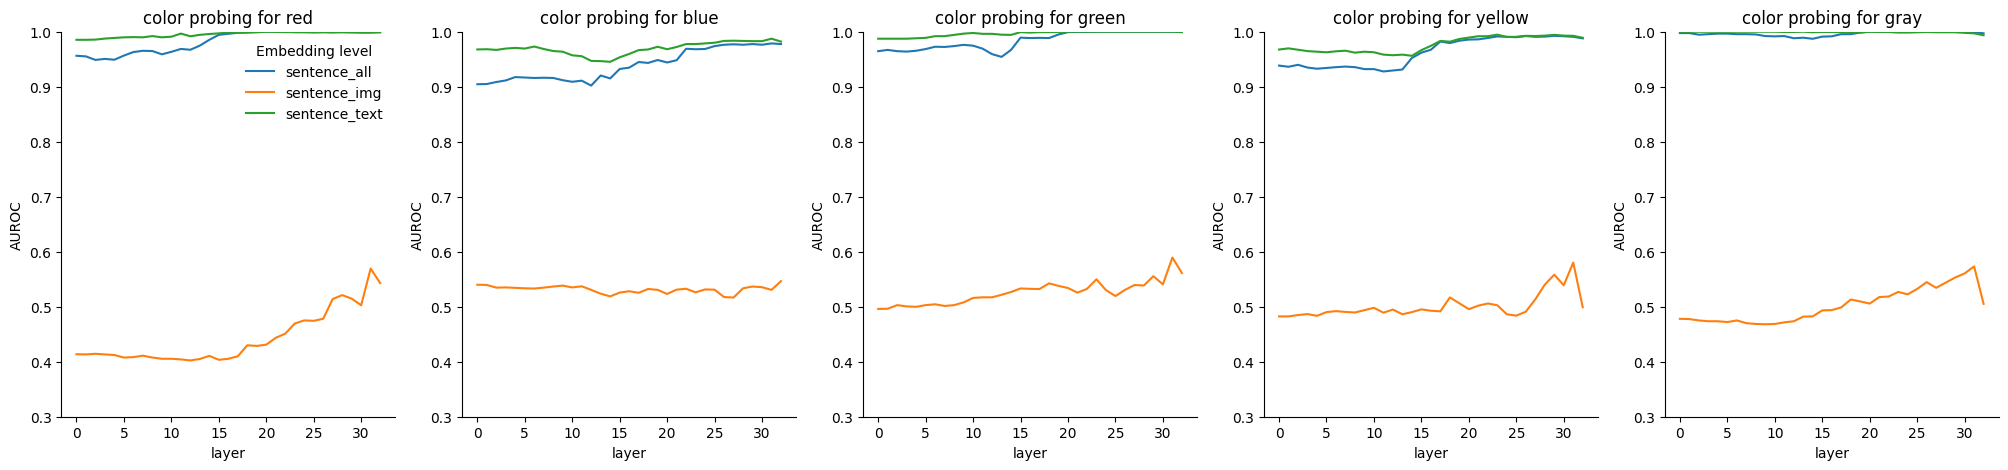

In [7]:
###### plot color probe results
task='color'
target=['red', 'blue','green','yellow', 'gray']
# target=['red','blue']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image_and_text'  # 'image', 'text'
nobject = 3

fig,axs = plt.subplots(1, len(target), figsize=(5*len(target), 5))

for idx, t in enumerate(target):
    plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/complex/probing_results_{task}_{t}_{nobject}.csv", index_col=0)
    plot_df['embeddings_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]
    b = sns.lineplot(data=plot_df[plot_df['embeddings_over']=='sentence'],
                     x='layer', y=metric, hue='embedding_level', 
                     ax=axs[idx])
    gold_reference = ['Yes' if t in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
    gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
    baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)

    # b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
    b.set_title(f"{task} probing for {t}")
    b.set_ylabel(metric.upper())

    if idx == 0:
        b.legend(frameon=False,
                 title='Embedding level')
    else:
        b.legend_.remove()

    b.set(ylim=(0.3,1))


sns.despine(top=True, right=True)

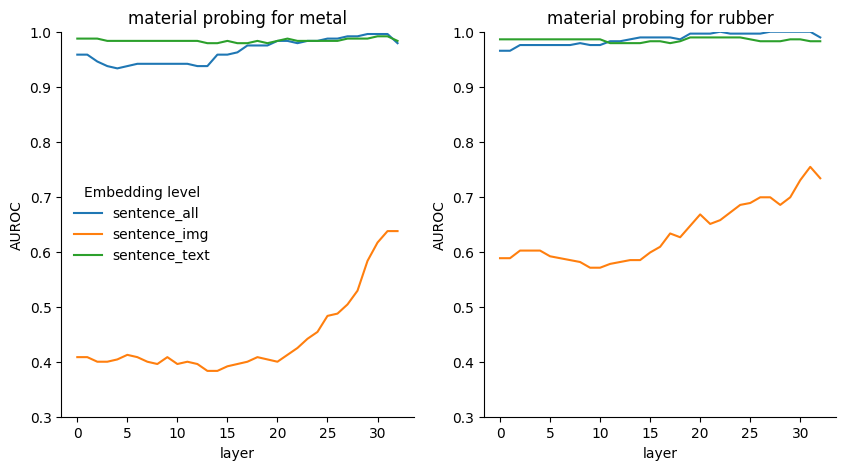

In [ ]:
###### plot material probe results
task='material'
target=['metal','rubber']
# target=['red','blue']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image_and_text'  # 'image', 'text'
nobject = 3

fig,axs = plt.subplots(1, len(target), figsize=(5*len(target), 5))

for idx, t in enumerate(target):
    plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/complex/probing_results_{task}_{t}_{nobject}.csv", index_col=0)
    plot_df['embeddings_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]
    b = sns.lineplot(data=plot_df[plot_df['embeddings_over']=='sentence'],
                     x='layer', y=metric, hue='embedding_level', 
                     ax=axs[idx])
    gold_reference = ['Yes' if t in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
    gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
    baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)

    b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
    b.set_title(f"{task} probing for {t}")
    b.set_ylabel(metric.upper())

    if idx == 0:
        b.legend(frameon=False,
                 title='Embedding level')
    else:
        b.legend_.remove()

    b.set(ylim=(0.3,1))


sns.despine(top=True, right=True)

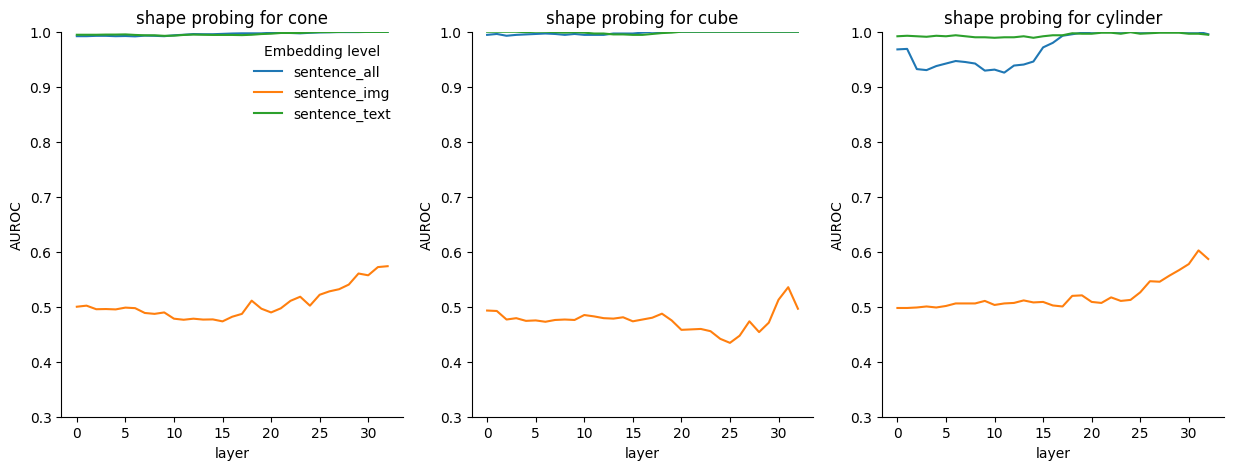

In [ ]:
###### plot shape probe results
task='shape'
target=['cone','cube', 'cylinder']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image_and_text'  # 'image', 'text'
nobject = 3

fig,axs = plt.subplots(1, len(target), figsize=(5*len(target), 5))

for idx, t in enumerate(target):
    plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/complex/probing_results_{task}_{t}_{nobject}.csv", index_col=0)
    plot_df['embeddings_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]
    b = sns.lineplot(data=plot_df[plot_df['embeddings_over']=='sentence'],
                     x='layer', y=metric, hue='embedding_level', 
                     ax=axs[idx])
    gold_reference = ['Yes' if t in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
    gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
    baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)

    b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
    b.set_title(f"{task} probing for {t}")
    b.set_ylabel(metric.upper())

    if idx == 0:
        b.legend(frameon=False,
                 title='Embedding level')
    else:
        b.legend_.remove()

    b.set(ylim=(0.3,1))


sns.despine(top=True, right=True)

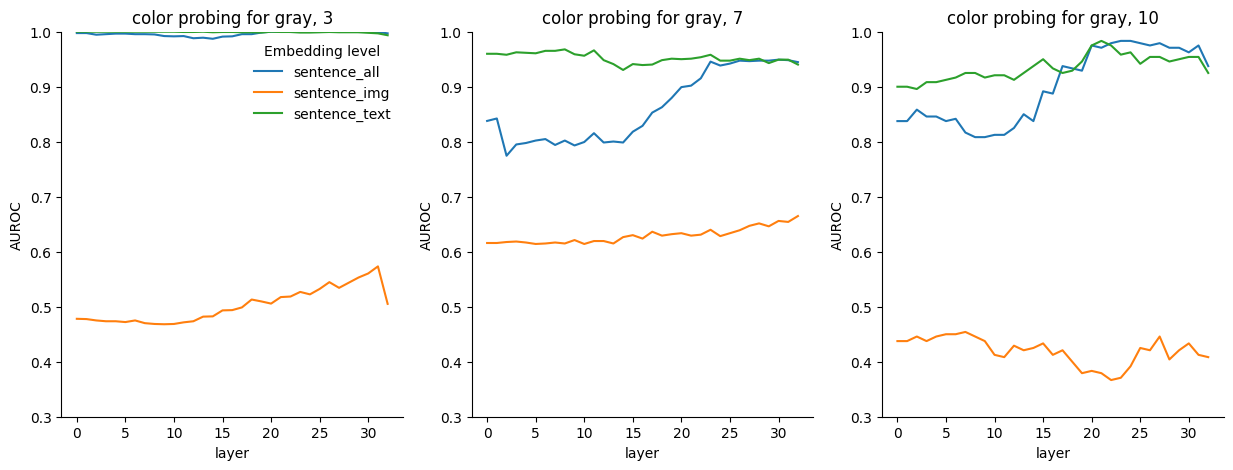

In [ ]:
###### plot shape probe results
tasks=['color']
targets=['gray']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
nobjects = [3, 7,10]
mode = 'image_and_text'  # 'image', 'text'

fig,axs = plt.subplots(len(targets), len(nobjects), figsize=(5*len(nobjects), 5*len(targets)))

for idx, nobject in enumerate(nobjects):
    for jdx, (target, task) in enumerate(zip(targets,tasks)):
        plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/complex/probing_results_{task}_{target}_{nobject}.csv", index_col=0)
        plot_df['embeddings_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]
        b = sns.lineplot(data=plot_df[plot_df['embeddings_over']=='sentence'],
                        x='layer', y=metric, hue='embedding_level', 
                        ax=axs[idx])
        gold_reference = ['Yes' if t in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
        gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
        baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)

        b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
        b.set_title(f"{task} probing for {target}, {nobject}")
        b.set_ylabel(metric.upper())

        if idx == 0:
            b.legend(frameon=False,
                    title='Embedding level')
        else:
            b.legend_.remove()

        b.set(ylim=(0.3,1))


sns.despine(top=True, right=True)

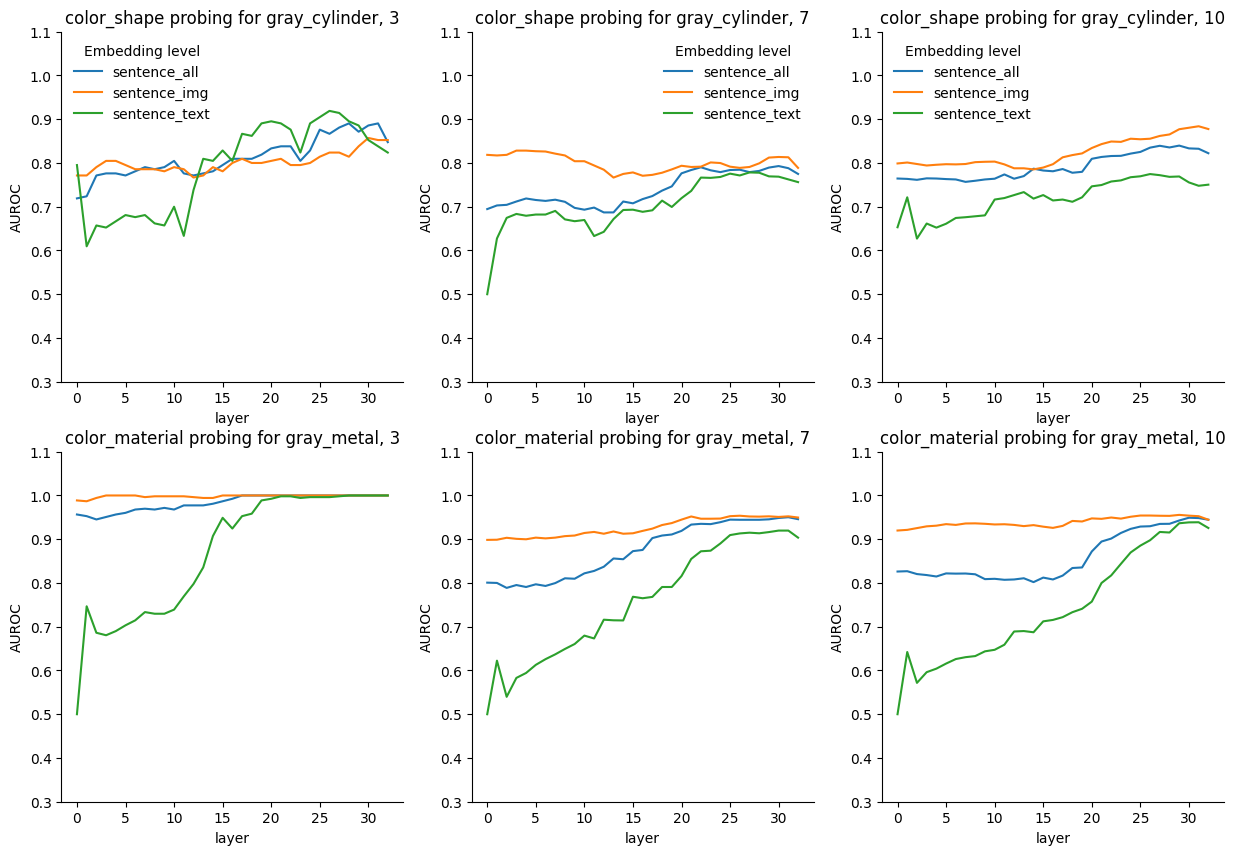

In [5]:
###### plot shape probe results
tasks=['color_shape', 'color_material']
targets=['gray_cylinder', 'gray_metal']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
nobjects = [3, 7, 10]
mode = 'image_and_text'  # 'image', 'text'

fig,axs = plt.subplots(len(targets), len(nobjects), figsize=(5*len(nobjects), 5*len(targets)))

for idx, (target, task) in enumerate(zip(targets,tasks)):   
    for jdx, nobject in enumerate(nobjects):
        plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/complex/probing_results_{task}_{target}_{nobject}.csv", index_col=0)
        plot_df['embeddings_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]
        b = sns.lineplot(data=plot_df[plot_df['embeddings_over']=='sentence'],
                        x='layer', y=metric, hue='embedding_level', 
                        ax=axs[idx][jdx])
        gold_reference = ['Yes' if target in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
        gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
        baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)

        b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
        b.set_title(f"{task} probing for {target}, {nobject}")
        b.set_ylabel(metric.upper())

        if idx == 0:
            b.legend(frameon=False,
                    title='Embedding level')
        else:
            b.legend_.remove()

        b.set(ylim=(0.3,1.1))


sns.despine(top=True, right=True)

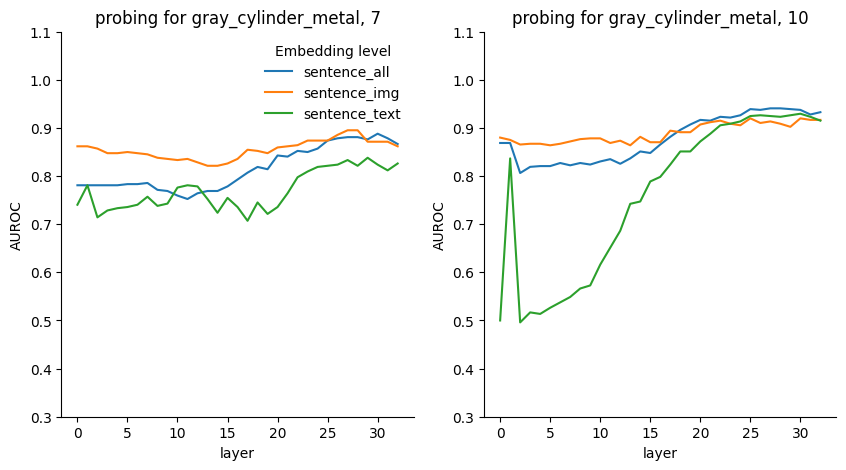

In [48]:
###### plot shape probe results
tasks=['color_shape_material']
targets=['gray_cylinder_metal']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image_and_text'  # 'image', 'text'
nobjects = [7,10]
fig,axs = plt.subplots(len(targets), len(nobjects), figsize=(5*len(nobjects), 5*len(targets)))

for idx, nobject in enumerate(nobjects):
    for jdx, (target, task) in enumerate(zip(targets,tasks)):
        plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/complex/probing_results_{task}_{target}_{nobject}.csv", index_col=0)
        plot_df['embeddings_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]
        b = sns.lineplot(data=plot_df[plot_df['embeddings_over']=='sentence'],
                        x='layer', y=metric, hue='embedding_level', 
                        ax=axs[idx])
        gold_reference = ['Yes' if t in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
        gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
        baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)

        b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
        b.set_title(f"probing for {target}, {nobject}")
        b.set_ylabel(metric.upper())

        if idx == 0:
            b.legend(frameon=False,
                    title='Embedding level')
        else:
            b.legend_.remove()

        b.set(ylim=(0.3,1.1))


sns.despine(top=True, right=True)